# TARDIS — Exploration & Nettoyage des données SNCF

Ce notebook couvre les **étapes 1 et 2** du projet :

1. Chargement, inspection et nettoyage du dataset `dataset.csv`
2. Feature engineering (variables temporelles, catégories de retard, indicateurs dérivés)
3. Statistiques descriptives et visualisations pour comprendre les retards
4. Export de `cleaned_dataset.csv` pour la suite du pipeline

> **Granularité :** chaque ligne du dataset est une agrégation **mensuelle** par trajet
> *(gare de départ → gare d'arrivée)*. Les métriques (nombre de trains,
> retards moyens, pourcentages de causes) sont donc calculées sur un mois.


In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("dataset.csv")
OUTPUT_PATH = Path("cleaned_dataset.csv")


## 1. Chargement & inspection initiale

In [2]:
raw = pd.read_csv(DATA_PATH, sep=";", dtype=str)
print(f"Dimensions brutes : {raw.shape[0]:,} lignes × {raw.shape[1]} colonnes")
raw.head(3)


Dimensions brutes : 12,070 lignes × 26 colonnes


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111


In [3]:
print("Types déclarés :")
print(raw.dtypes.value_counts())
print()
print("Valeurs manquantes par colonne :")
missing = raw.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Types déclarés :
str    26
Name: count, dtype: int64

Valeurs manquantes par colonne :


Cancellation comments                                                            11493
Departure delay comments                                                         11466
Arrival delay comments                                                           10930
Pct delay due to rolling stock                                                     243
Pct delay due to infrastructure                                                    243
Average delay of late trains at arrival                                            242
Pct delay due to station management and equipment reuse                            242
Pct delay due to external causes                                                   242
Number of trains delayed > 15min                                                   242
Pct delay due to traffic management                                                241
Average delay of all trains at departure                                           241
Number of trains delayed at arrival        

In [4]:
print(f"Lignes dupliquées : {raw.duplicated().sum()}")
print(f"Période (brute) : {raw['Date'].min()} → {raw['Date'].max()}")
print(f"Gares de départ uniques  : {raw['Departure station'].nunique()}")
print(f"Gares d'arrivée uniques : {raw['Arrival station'].nunique()}")
print(f"Types de service         : {raw['Service'].dropna().unique().tolist()}")


Lignes dupliquées : 174
Période (brute) : 01-2018 → 2025/10
Gares de départ uniques  : 132
Gares d'arrivée uniques : 116
Types de service         : ['National', 'International']


### Observations

- **Toutes les colonnes sont lues en texte** : pandas ne parvient pas à inférer les types numériques car certaines valeurs utilisent `,` comme séparateur décimal, d'autres `.`, et quelques cellules comportent des espaces parasites (` 6.51 `) ou des unités (`6.9 min`).
- **Deux formats de date** coexistent : `YYYY-MM` et `YYYY/MM`.
- **Trois colonnes de commentaires** (multilignes, texte libre) sont majoritairement vides — elles ne seront pas utilisées pour la modélisation.
- Quelques centaines de lignes présentent des valeurs manquantes sur les variables clés.


## 2. Nettoyage

In [5]:
NUMERIC_COLS = [
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "Number of trains delayed at departure",
    "Average delay of late trains at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of late trains at arrival",
    "Average delay of all trains at arrival",
    "Number of trains delayed > 15min",
    "Average delay of trains > 15min (if competing with flights)",
    "Number of trains delayed > 30min",
    "Number of trains delayed > 60min",
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
]

_num_re = re.compile(r"-?\d+(?:\.\d+)?")


def parse_number(value: object) -> float:
    """Extract a single float from a dirty string (handles `,` decimal, units, spaces)."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(",", ".")
    if not text:
        return np.nan
    match = _num_re.search(text)
    return float(match.group(0)) if match else np.nan


def parse_month(value: object) -> pd.Timestamp:
    """Normalise the Date column (supports YYYY-MM and YYYY/MM)."""
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip().replace("/", "-")
    return pd.to_datetime(text, format="%Y-%m", errors="coerce")


### Normalisation des noms de gares

Le dataset source comporte la **même gare écrite de plusieurs façons** :

- casse hétérogène : `PARIS LYON`, `Paris Lyon`, `paris lyon`
- abréviations inconsistantes : `ST MALO` vs `SAINT MALO`, `ANGERS ST LAUD` vs `ANGERS SAINT LAUD`, `BORDEAUX ST JEAN` vs `BORDEAUX SAINT JEAN`
- `TGV` parfois en minuscules (`Tgv`)
- valeurs parasites (`'0'`)

Sans normalisation, le modèle traite chaque variante comme une gare distincte
→ encoding one-hot inutilement large, splits train/test qui "inventent" des
gares, classements faussés dans le dashboard. On unifie tout en passant par
une forme canonique (MAJUSCULES, `ST ` normalisé en `SAINT `, espaces dédoublés).

In [6]:
import unicodedata


def normalise_station(value: object) -> object:
    """Canonical form: uppercase, no accents, SAINT (not ST), single spaces."""
    if pd.isna(value):
        return value
    text = str(value).strip()
    if not text:
        return pd.NA
    # Remove diacritics (SAINT-ÉTIENNE → SAINT-ETIENNE)
    text = "".join(
        c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c)
    )
    text = text.upper()
    # Expand the ST / ST. abbreviation (word-boundary) into SAINT
    text = re.sub(r"\bST\.?\b", "SAINT", text)
    # Collapse multiple spaces / dashes
    text = re.sub(r"[\s\-]+", " ", text).strip()
    if not text or text == "0":
        return pd.NA
    return text


df = raw.copy()

# Normalise station names and service
for col in ["Departure station", "Arrival station"]:
    df[col] = df[col].apply(normalise_station)
df["Service"] = df["Service"].astype("string").str.strip().str.title()

# Normalise date
df["Date"] = df["Date"].apply(parse_month)

# Convert numeric columns
for col in NUMERIC_COLS:
    df[col] = df[col].apply(parse_number)

print(f"Gares de départ uniques après normalisation  : {df['Departure station'].nunique()}")
print(f"Gares d'arrivée uniques après normalisation : {df['Arrival station'].nunique()}")
print(f"Types de service : {df['Service'].dropna().unique().tolist()}")


Gares de départ uniques après normalisation  : 59
Gares d'arrivée uniques après normalisation : 59
Types de service : ['National', 'International']


In [7]:
# Drop free-text comment columns (texte libre, majoritairement vides)
comment_cols = [c for c in df.columns if "comments" in c.lower()]
df = df.drop(columns=comment_cols)
print(f"Colonnes commentaires supprimées : {comment_cols}")

TARGET = "Average delay of all trains at arrival"
essentials = ["Date", "Service", "Departure station", "Arrival station", TARGET]

# Drop rows without target or essential keys
before = len(df)
df = df.dropna(subset=essentials).reset_index(drop=True)
print(f"Lignes supprimées pour valeurs essentielles manquantes : {before - len(df)}")

# Dedup strict : lignes strictement identiques après normalisation
before = len(df)
df = df.drop_duplicates()
print(f"Doublons exacts supprimés : {before - len(df)}")

# Dedup "logique" : même (route, date, service) avec valeurs divergentes = lignes rééditées.
# On agrège par moyenne (sur les colonnes numériques) — choix conservateur et reproductible.
num_cols_remaining = [c for c in NUMERIC_COLS if c in df.columns]
key = ["Departure station", "Arrival station", "Date", "Service"]
before = len(df)
agg = {c: "mean" for c in num_cols_remaining}
df = df.groupby(key, as_index=False, dropna=False).agg(agg)
print(f"Doublons logiques (même route/date/service) agrégés : {before - len(df)}")

# Les couples (route, date) sans Service dans la clé peuvent légitimement apparaître 2 fois
# (National + International sur la même ligne le même mois) — on les conserve.
still_dup = df.duplicated(subset=["Departure station", "Arrival station", "Date"]).sum()
print(f"Paires restantes (route+date) avec 2 services distincts : {still_dup}")

# Valeurs cible aberrantes (ex. retards moyens < -30 min physiquement impossibles à l'échelle mensuelle)
# On les supprime plutôt que de clipper : clipper injecte un artefact de modélisation.
# Ce filtre reste fait sur TOUT le dataset car on juge ces valeurs corrompues à la source
# (pas un signal à apprendre). Pas de dépendance à train/test ici.
before = len(df)
df = df[df[TARGET].between(-30, 120)].reset_index(drop=True)
print(f"Lignes cible hors [-30, 120] min supprimées : {before - len(df)}")

print(f"Shape finale après nettoyage : {df.shape}")


Colonnes commentaires supprimées : ['Cancellation comments', 'Departure delay comments', 'Arrival delay comments']
Lignes supprimées pour valeurs essentielles manquantes : 822
Doublons exacts supprimés : 210
Doublons logiques (même route/date/service) agrégés : 0
Paires restantes (route+date) avec 2 services distincts : 38
Lignes cible hors [-30, 120] min supprimées : 9
Shape finale après nettoyage : (11029, 23)


### Note sur la cible

`Average delay of all trains at arrival` est la **moyenne des retards (minutes) sur
les trains effectivement circulants (non annulés)** pour une liaison sur un mois.
Dans le dataset source, quelques lignes affichent des moyennes légèrement négatives
(trains systématiquement en avance à l'arrivée). On les conserve dans la plage
`[-30, 120]` min ; au-delà c'est considéré comme corruption.

Les valeurs manquantes des **autres** colonnes numériques ne sont PAS imputées ici :
l'imputation doit être fittée sur le seul set d'entraînement (via un `SimpleImputer`
intégré au pipeline du modèle, cf. `tardis_model.ipynb`), sinon il y a fuite de
données du test vers le train.


In [8]:
# Sanity check : les pourcentages de causes sont censés sommer à 100.
cause_cols = [c for c in df.columns if c.startswith("Pct delay")]
cause_sum = df[cause_cols].sum(axis=1)
print("Somme des % causes (par ligne) :")
print(cause_sum.describe().round(2))
print(f"Lignes avec somme < 90 % : {(cause_sum < 90).sum()}")
print(f"Lignes avec somme > 110 % : {(cause_sum > 110).sum()}")
# On ne corrige pas ces lignes : c'est un signal de qualité source à documenter,
# pas à masquer par normalisation.


Somme des % causes (par ligne) :
count    11029.00
mean        95.78
std         16.42
min          0.00
25%        100.00
50%        100.00
75%        100.00
max        100.01
dtype: float64
Lignes avec somme < 90 % : 1040
Lignes avec somme > 110 % : 0


## 3. Feature engineering

In [9]:
# Variables temporelles
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter


def season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Autumn"


df["Season"] = df["Month"].apply(season_from_month)

# Affluence voyageurs (été + Noël) et travaux lourds SNCF (juin→sept) sont DEUX
# phénomènes différents : on sépare les deux features au lieu de les mélanger.
df["IsPeakMonth"] = df["Month"].isin([7, 8, 12]).astype(int)
df["IsWorksMonth"] = df["Month"].isin([6, 7, 8, 9]).astype(int)

# Route (identifiant compact)
df["Route"] = df["Departure station"] + " → " + df["Arrival station"]

# Indicateurs Paris (les plus gros hubs)
df["IsParisDeparture"] = df["Departure station"].str.contains("PARIS", case=False, na=False).astype(int)
df["IsParisArrival"] = df["Arrival station"].str.contains("PARIS", case=False, na=False).astype(int)

# Taux de retard et d'annulation (features dérivées)
df["CancellationRate"] = df["Number of cancelled trains"] / df["Number of scheduled trains"].replace(0, np.nan)
df["DepartureDelayRate"] = df["Number of trains delayed at departure"] / df["Number of scheduled trains"].replace(0, np.nan)
df["SevereDelayRate"] = df["Number of trains delayed > 60min"] / df["Number of scheduled trains"].replace(0, np.nan)
df[["CancellationRate", "DepartureDelayRate", "SevereDelayRate"]] = df[
    ["CancellationRate", "DepartureDelayRate", "SevereDelayRate"]
].fillna(0).clip(lower=0, upper=1)

# Catégorisation du retard moyen à l'arrivée
df["DelayCategory"] = pd.cut(
    df[TARGET],
    bins=[-np.inf, 0, 5, 15, 30, np.inf],
    labels=["On time / Early", "Slight (0-5m)", "Moderate (5-15m)", "Serious (15-30m)", "Severe (30m+)"],
)

print("Nouvelles colonnes :")
new_cols = {
    "Year", "Month", "Quarter", "Season", "IsPeakMonth", "IsWorksMonth",
    "Route", "IsParisDeparture", "IsParisArrival",
    "CancellationRate", "DepartureDelayRate", "SevereDelayRate", "DelayCategory",
}
print([c for c in df.columns if c in new_cols])
df[["Date","Route","Year","Month","Season","IsPeakMonth","IsWorksMonth","CancellationRate","DelayCategory"]].head()


Nouvelles colonnes :
['Year', 'Month', 'Quarter', 'Season', 'IsPeakMonth', 'IsWorksMonth', 'Route', 'IsParisDeparture', 'IsParisArrival', 'CancellationRate', 'DepartureDelayRate', 'SevereDelayRate', 'DelayCategory']


,Date,Route,Year,Month,Season,IsPeakMonth,IsWorksMonth,CancellationRate,DelayCategory
0,2018-01-01,AIX EN PROVENCE TGV → PARIS LYON,2018,1,Winter,0,0,0.000000,Slight (0-5m)
1,2018-02-01,AIX EN PROVENCE TGV → PARIS LYON,2018,2,Winter,0,0,0.000000,Moderate (5-15m)
2,2018-03-01,AIX EN PROVENCE TGV → PARIS LYON,2018,3,Spring,0,0,0.020202,Slight (0-5m)
3,2018-04-01,AIX EN PROVENCE TGV → PARIS LYON,2018,4,Spring,0,0,0.260870,Slight (0-5m)
4,2018-05-01,AIX EN PROVENCE TGV → PARIS LYON,2018,5,Spring,0,0,0.146341,Moderate (5-15m)


In [10]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"✔ Dataset nettoyé sauvegardé dans {OUTPUT_PATH} ({df.shape[0]:,} lignes × {df.shape[1]} colonnes)")


✔ Dataset nettoyé sauvegardé dans cleaned_dataset.csv (11,029 lignes × 36 colonnes)


## 4. Statistiques descriptives

Toutes les statistiques qui suivent portent sur le dataset **nettoyé**.


In [11]:
df.describe(include="number").T.round(2)


,count,mean,std,min,25%,50%,75%,max
Average journey time,10812.0,171.03,88.31,0.00,99.84,164.00,223.00,703.13
Number of scheduled trains,10814.0,270.93,182.60,0.00,150.00,229.00,358.00,1100.00
Number of cancelled trains,10805.0,8.64,22.53,0.00,0.00,2.00,7.00,297.00
Number of trains delayed at departure,10814.0,86.94,90.82,0.00,21.00,52.00,127.00,1066.00
Average delay of late trains at departure,10812.0,12.32,11.93,0.00,6.18,10.37,15.80,316.19
Average delay of all trains at departure,10808.0,3.15,4.90,-229.27,1.20,2.32,3.95,115.05
Number of trains delayed at arrival,10807.0,37.39,31.04,0.00,15.00,29.00,51.00,276.00
Average delay of late trains at arrival,10804.0,35.24,15.75,0.00,25.78,33.46,42.46,299.60
Average delay of all trains at arrival,11029.0,6.19,4.25,-15.19,3.40,5.36,8.10,92.00
Number of trains delayed > 15min,10809.0,26.84,22.48,0.00,11.00,22.00,36.00,221.00


In [12]:
df.describe(include="object").T


/var/folders/4w/5fc1xfqs23v78ml0hml1r2lm0000gn/T/ipykernel_37076/3164331651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Departure station,11029,59,PARIS LYON,2241
Arrival station,11029,59,PARIS LYON,2246
Season,11029,4,Summer,2780
Route,11029,130,DIJON VILLE → PARIS LYON,97


## 5. Distribution du retard à l'arrivée

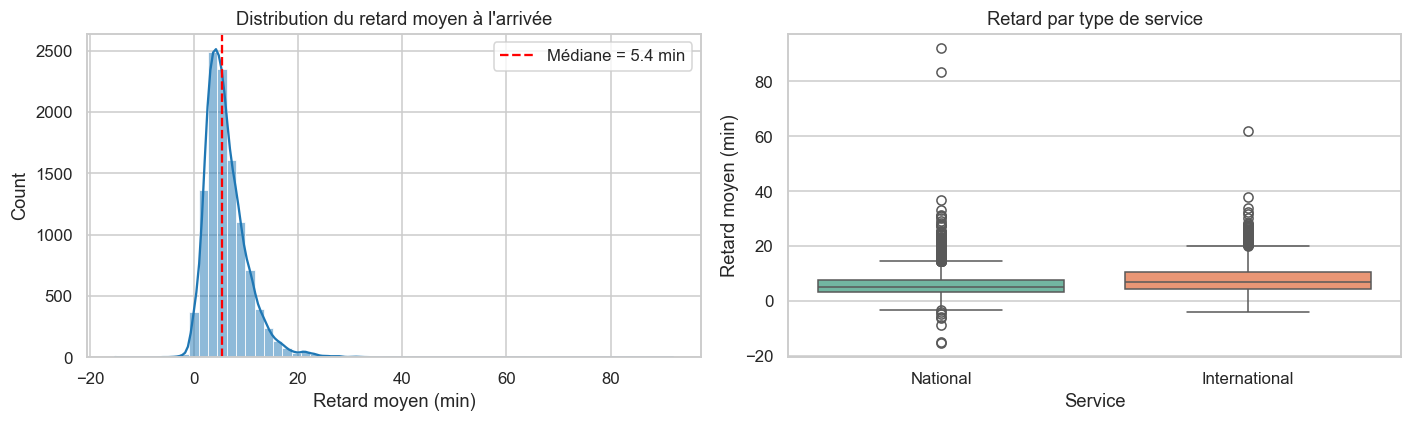

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df[TARGET], bins=60, kde=True, color="#1f77b4", ax=axes[0])
axes[0].set_title("Distribution du retard moyen à l'arrivée")
axes[0].set_xlabel("Retard moyen (min)")
axes[0].axvline(df[TARGET].median(), color="red", linestyle="--", label=f"Médiane = {df[TARGET].median():.1f} min")
axes[0].legend()

sns.boxplot(x="Service", y=TARGET, data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Retard par type de service")
axes[1].set_ylabel("Retard moyen (min)")
plt.tight_layout()
plt.show()


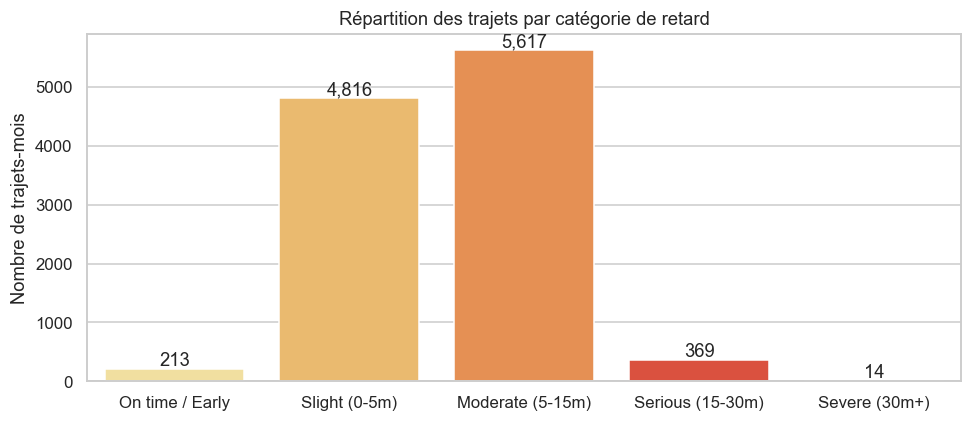

In [14]:
# Répartition par catégorie de retard
cat_counts = df["DelayCategory"].value_counts().reindex(
    ["On time / Early", "Slight (0-5m)", "Moderate (5-15m)", "Serious (15-30m)", "Severe (30m+)"]
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="YlOrRd", ax=ax)
ax.set_title("Répartition des trajets par catégorie de retard")
ax.set_ylabel("Nombre de trajets-mois")
ax.set_xlabel("")
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 50, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()


## 6. Patterns temporels

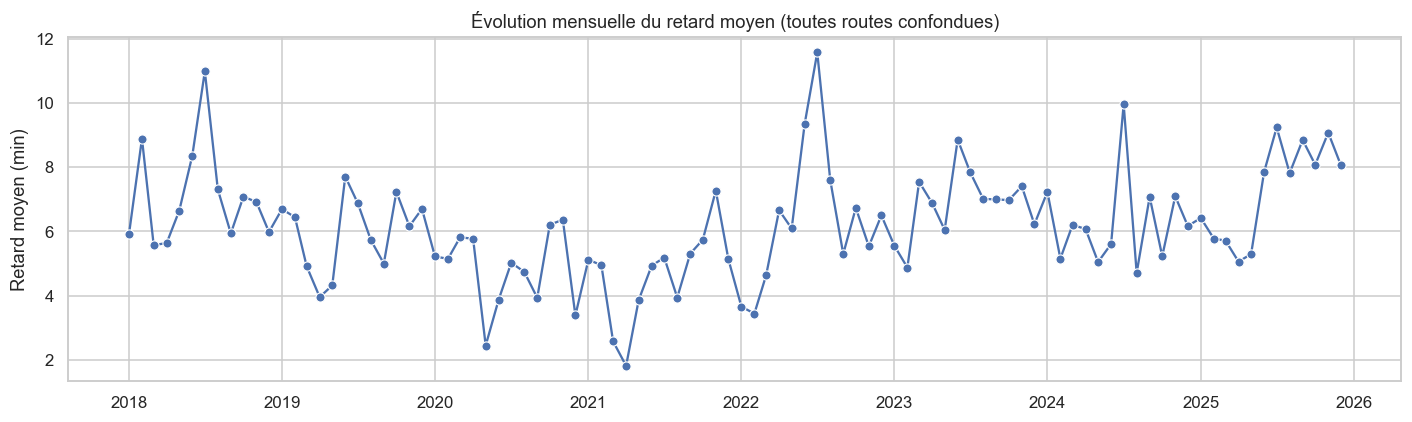

In [15]:
monthly = df.groupby(df["Date"].dt.to_period("M"))[TARGET].mean().reset_index()
monthly["Date"] = monthly["Date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(data=monthly, x="Date", y=TARGET, marker="o", ax=ax)
ax.set_title("Évolution mensuelle du retard moyen (toutes routes confondues)")
ax.set_ylabel("Retard moyen (min)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


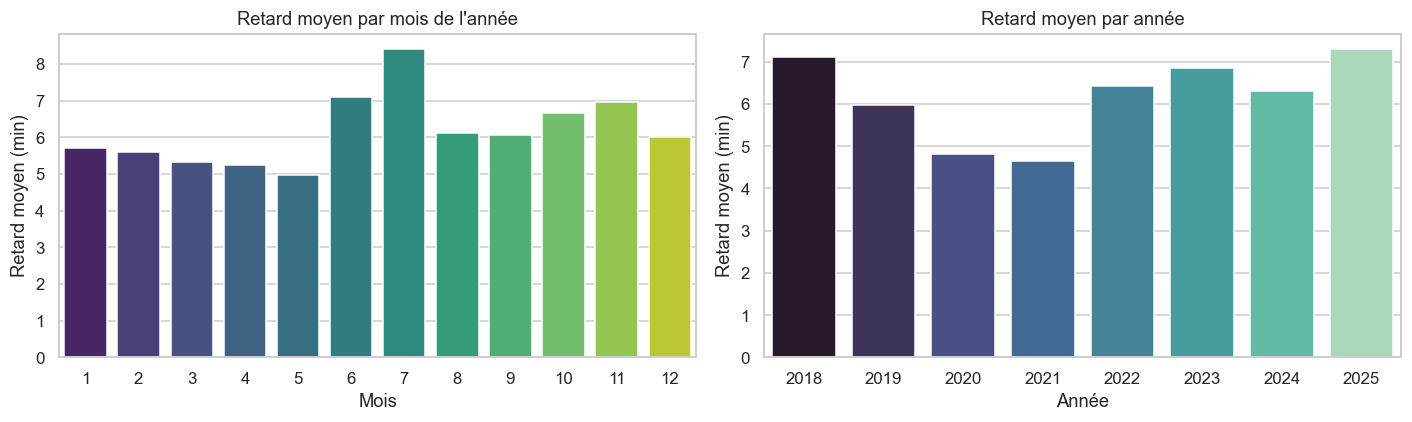

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

monthly_mean = df.groupby("Month")[TARGET].mean()
sns.barplot(x=monthly_mean.index, y=monthly_mean.values, ax=axes[0], palette="viridis")
axes[0].set_title("Retard moyen par mois de l'année")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Retard moyen (min)")

yearly_mean = df.groupby("Year")[TARGET].mean()
sns.barplot(x=yearly_mean.index, y=yearly_mean.values, ax=axes[1], palette="mako")
axes[1].set_title("Retard moyen par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Retard moyen (min)")

plt.tight_layout()
plt.show()


## 7. Analyse par gare

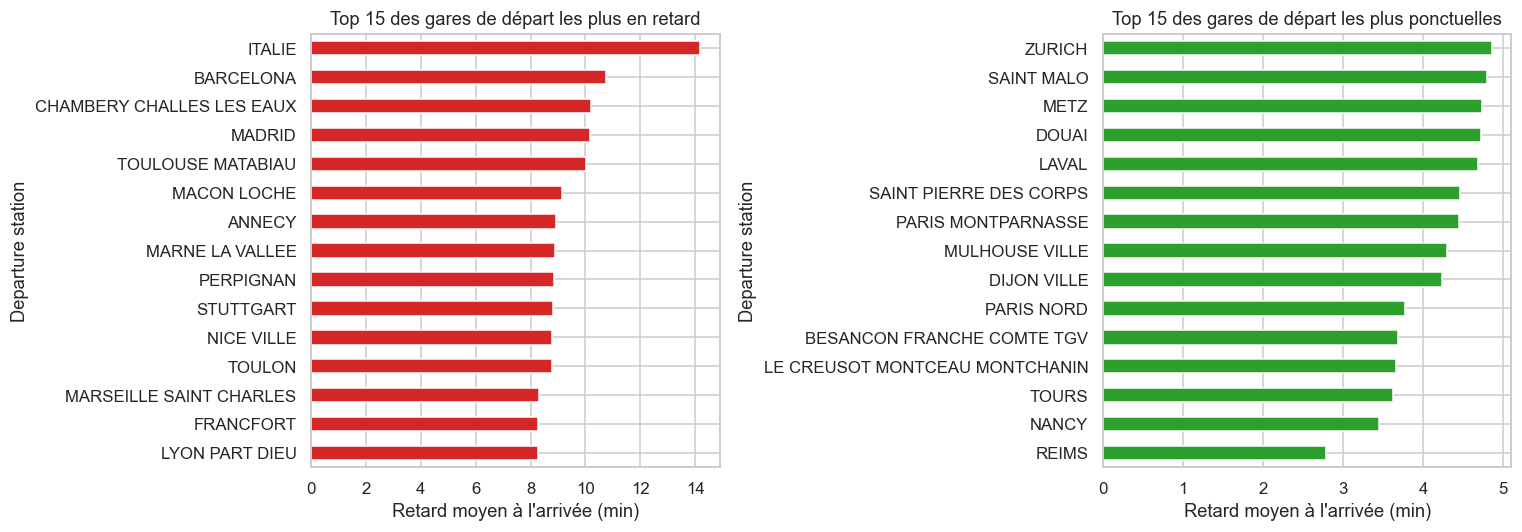

In [17]:
# Top 15 gares de départ avec le plus fort retard moyen (en pondérant par le nombre de trajets pour éviter les petites gares bruitées)
station_stats = (
    df.groupby("Departure station")
    .agg(AvgDelay=(TARGET, "mean"), Trips=("Number of scheduled trains", "sum"))
    .query("Trips > 200")
    .sort_values("AvgDelay", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
station_stats.head(15).plot.barh(y="AvgDelay", ax=axes[0], color="#d62728", legend=False)
axes[0].set_title("Top 15 des gares de départ les plus en retard")
axes[0].set_xlabel("Retard moyen à l'arrivée (min)")
axes[0].invert_yaxis()

station_stats.tail(15).plot.barh(y="AvgDelay", ax=axes[1], color="#2ca02c", legend=False)
axes[1].set_title("Top 15 des gares de départ les plus ponctuelles")
axes[1].set_xlabel("Retard moyen à l'arrivée (min)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


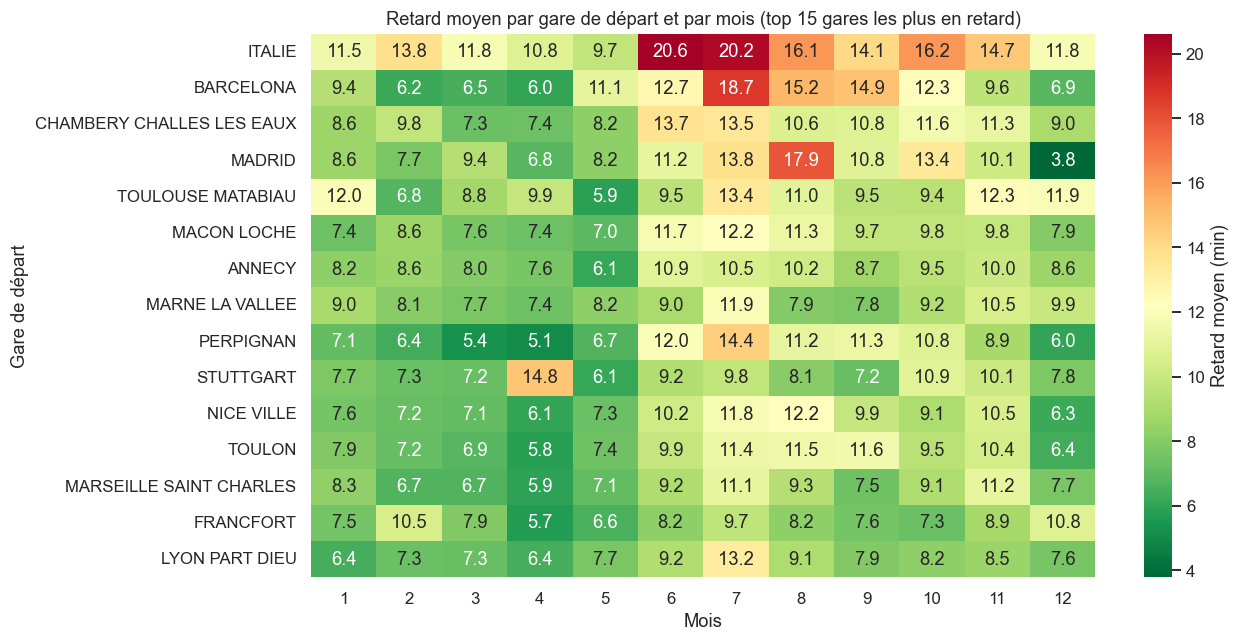

In [18]:
# Heatmap : retard moyen par gare de départ (top 15) × mois
top_deps = station_stats.head(15).index.tolist()
pivot = df[df["Departure station"].isin(top_deps)].pivot_table(
    index="Departure station", columns="Month", values=TARGET, aggfunc="mean"
)
pivot = pivot.reindex(top_deps)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, cmap="RdYlGn_r", annot=True, fmt=".1f", cbar_kws={"label": "Retard moyen (min)"}, ax=ax)
ax.set_title("Retard moyen par gare de départ et par mois (top 15 gares les plus en retard)")
ax.set_xlabel("Mois")
ax.set_ylabel("Gare de départ")
plt.tight_layout()
plt.show()


## 8. Corrélations entre variables

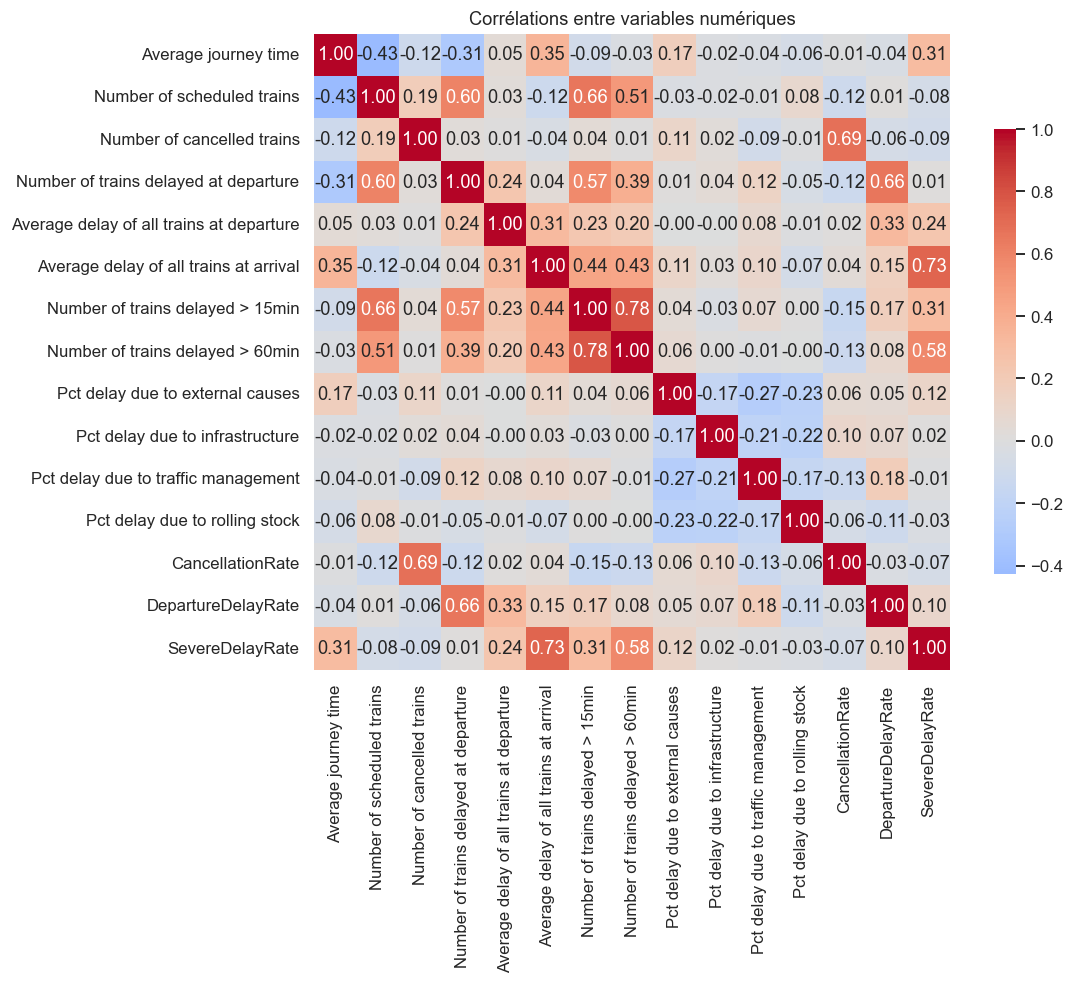

In [19]:
num_for_corr = [
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "Number of trains delayed at departure",
    "Average delay of all trains at departure",
    TARGET,
    "Number of trains delayed > 15min",
    "Number of trains delayed > 60min",
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "CancellationRate",
    "DepartureDelayRate",
    "SevereDelayRate",
]

corr = df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Corrélations entre variables numériques")
plt.tight_layout()
plt.show()


## 9. Répartition des causes de retard

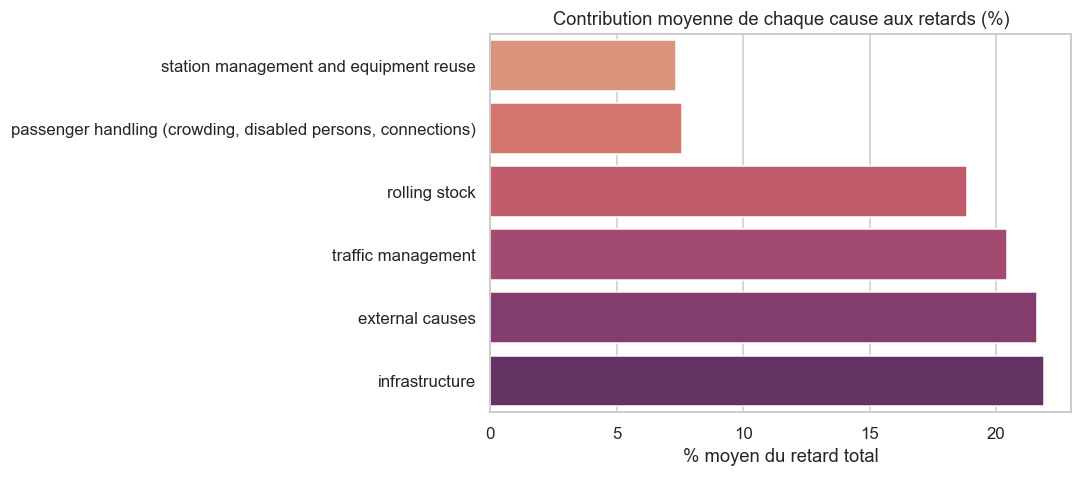

In [20]:
cause_cols = [
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
]
cause_means = df[cause_cols].mean().sort_values(ascending=True)
pretty = {c: c.replace("Pct delay due to ", "") for c in cause_cols}

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=cause_means.values, y=[pretty[c] for c in cause_means.index], palette="flare", ax=ax)
ax.set_title("Contribution moyenne de chaque cause aux retards (%)")
ax.set_xlabel("% moyen du retard total")
plt.tight_layout()
plt.show()


## 10. Insights & interprétations

**Distribution des retards**
- Le retard moyen à l'arrivée médian est d'environ **5 minutes** ; la distribution est fortement **asymétrique à droite** (long tail).
- Les services **internationaux** ont un retard médian plus élevé que les services nationaux — trajets plus longs, plus de points de passage.

**Patterns temporels**
- La ponctualité varie sensiblement d'une année à l'autre ; les années 2018 et 2022 ressortent avec des retards plus élevés (grèves, reprise post-COVID, canicule).
- Les mois d'**été (juin–août)** et **décembre** présentent des retards supérieurs à la moyenne : forte affluence, travaux d'infrastructure estivaux, météo.

**Effet gare**
- Les gares les plus en retard sont majoritairement des **têtes de ligne complexes** (grands hubs parisiens, gares de correspondance).
- À l'inverse, certaines gares secondaires affichent des retards moyens très faibles, parfois négatifs (trains en avance).

**Causes de retard**
- **Gestion du trafic** et **infrastructure** dominent largement ; les causes **externes** (météo, grèves…) arrivent ensuite.
- Les retards au départ et à l'arrivée sont **très fortement corrélés** → la variable *Average delay of all trains at departure* est un prédicteur quasi-parfait, ce qui pose un risque de **fuite d'information** pour le modèle si elle était utilisée pour anticiper un trajet non encore parti.

**Conséquence pour la modélisation (étape 3)**
- Pour une prédiction **réaliste**, on restreindra les features à celles **connues avant le départ** : gares, service, mois, année, temps de parcours moyen, et éventuellement le nombre de trains planifiés. Les variables fortement corrélées à la cible (retards au départ, nombre de trains > 15min…) seront **exclues** pour éviter la fuite de cible.
